##    MP307 Practical 3 Discrete Population Models

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

## Q.1(*) Geometric Population Model
Consider the geometric population model $P_{n+1}=(1+r)P_{n}$ for $n=0,1,\ldots$ with solution $
P_{n}=P_{0}e^{sn}$ for $s=\log (1+r)$ as a model of 
 1. Sweden's population with 11 samples from 1750 to 1960 
 2. The US population with 19 samples from 1790 to 1990.

 ### Population of Sweden
 The data (in millions) are given in the lists `Year` and `Pop` below.

In [2]:
Year = [1750, 1770, 1790, 1810, 1830, 1850, 1870, 1890, 1910, 1930, 1960]
Pop= [1.76, 2.03, 2.158, 2.378, 2.888, 3.48, 4.17, 4.785, 5.522, 6.14, 7.49]
len(Pop)

11

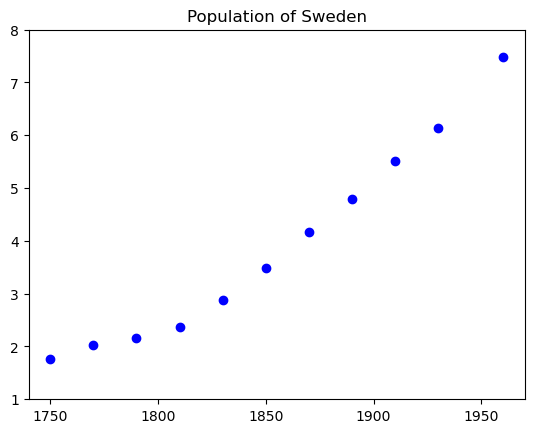

In [3]:
plt.figure(1)
plt.plot(Year,Pop,'bo')
plt.axis([1740,1970,1,8])
plt.title('Population of Sweden')
plt.show()

Look at t vs log(P):

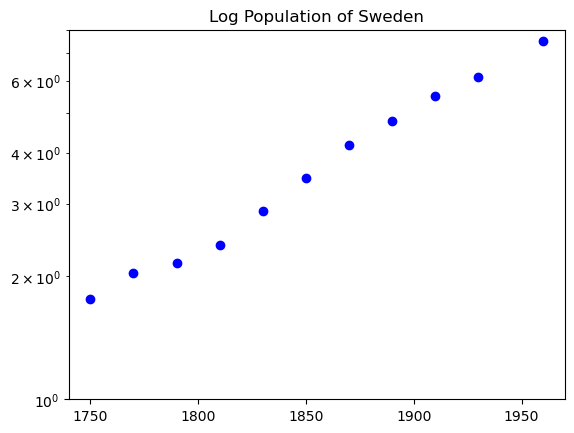

In [4]:
plt.figure(2) # new figure
plt.plot(Year,Pop,'bo')
plt.yscale("log")
plt.axis([1740,1970,1,8])
plt.title('Log Population of Sweden')
plt.show()

The log plot suggest a linear relationship to between $\log P$ and $t$ of the form $\log P(t)=st+b$ for some $s,b$. Thus $P(t)=P_{0}e^{st}$ with $P_{0}=\exp(b)$. 

In [5]:
log_Pop=np.log(Pop) # take log of each entry in S_Pop

In [6]:
print(log_Pop)

[0.56531381 0.70803579 0.76918187 0.8662598  1.06056422 1.24703229
 1.42791604 1.56548602 1.70874011 1.81482474 2.0135688 ]


Use a least squares approximation to find a line as explained in the notes for matching data $x_{i}$ to $y_{i}$.  

In [7]:
N=len(Year) # no of elements in S_Year
sumx=0; sumy=0; sumxx=0; sumxy=0; 
for i in range(N):
    sumx=sumx+Year[i]
    sumy=sumy+log_Pop[i]
    sumxx=sumxx+Year[i]**2
    sumxy=sumxy+log_Pop[i]*Year[i]
Xbar=sumx/N
Ybar=sumy/N
XXbar=sumxx/N
XYbar=sumxy/N

In [8]:
s=(XYbar-Xbar*Ybar)/(XXbar-Xbar**2)
b=(XXbar*Ybar-Xbar*XYbar)/(XXbar-Xbar**2)

P_0=np.exp(b)
print(s,P_0)

0.0072182711579564076 5.500654960458621e-06


Plot population $P(t)=P_{0}e^{st}$ vs $t$.

In [9]:
t=np.arange(1740.0,1970.,5.)
P_LS=P_0*np.exp(s*t) # least squares approximation

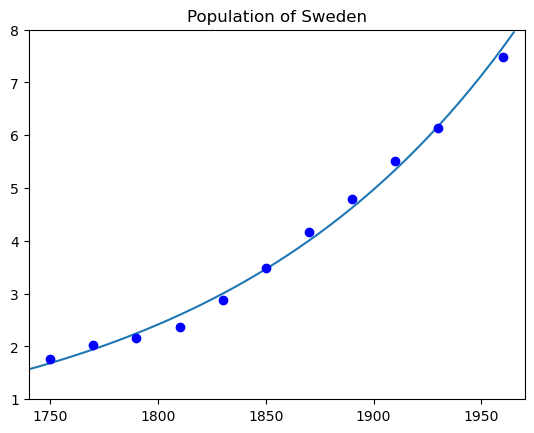

In [10]:
plt.figure(3)
plt.plot(t,P_LS)
plt.plot(Year,Pop,'bo')
plt.axis([1740,1970,1,8])
plt.title('Population of Sweden')
plt.show()

###  Repeat this analysis for the US population as follows:

In [11]:
Year = [1790, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990]
Pop= [3.79, 9.6, 12.9, 17.1, 23.2, 31.4, 38.6, 50.2, 62.9, 76.0, 92.0, 106.5, 123.2, 132.0, 151.3, 179.3, 203.3, 226.54, 248.7]

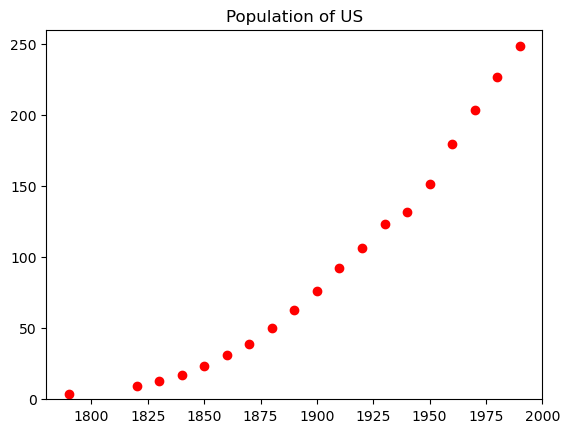

In [12]:
plt.figure(4)
plt.plot(Year,Pop,'ro')
plt.axis([1780,2000,0,260])
plt.title('Population of US')
plt.show()

In [13]:
log_Pop=np.log(Pop)

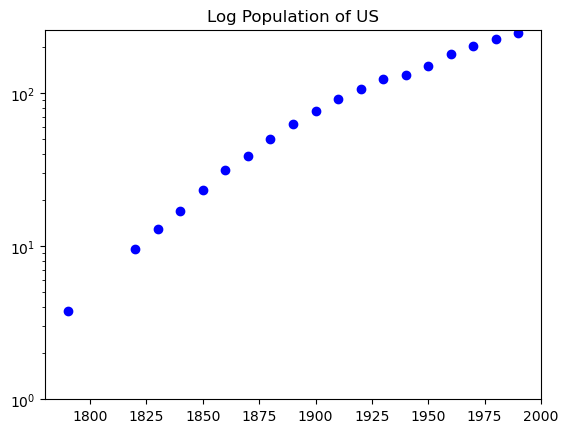

In [14]:
plt.figure(5) # new figure
plt.plot(Year,Pop,'bo')
plt.yscale("log")
plt.axis([1780,2000,1,260])
plt.title('Log Population of US')
plt.show()

## TASK:
Get the parameters for a least square fit to the US data. Plot the data and the fitted equation. 
It should end up looking something like this

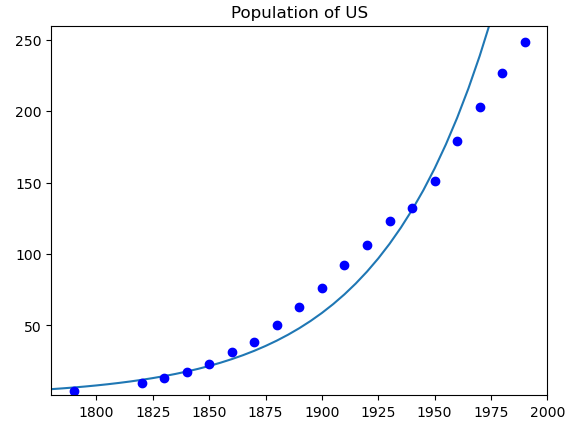

## Q.2 (*) Discrete Verhulst Model
The general discrete Verhulst model of population growth is as follows 
$$
P_{n+1}=\dfrac{1+r}{1+\dfrac{rP_{n}}{K}}P_{n} 
$$
where $P_{n}\rightarrow K$ as $n\rightarrow \infty $. 

For the choice of
parameters $P_{0}=3.79$, $r=0.35$ and $K=300$ compare the Verhulst model to
the US population from 1790 to 1990. Explain what you see.

In [17]:
print(Year)

[1790, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990]


In [18]:
P_0=3.79
r=0.35
K=300.0

In [19]:
# plot Verhulst pop PV from 1790 to 1990 with 10 year intervals
PV=[0]*20 # list for Verhulst P initialized with 20 zeros
YV=[0]*20 # list for years initialized with 20 zeros

PV[0]=P_0
YV[0]=1790
# choose 10 year intervals
for n in range(1,20):
    YV[n]=1790+10*n
    PV[n]= #fill this in yourself
    

## TASK:
Use the Verhulst model to get populations for the years in `Year` and compare with the corresponding data. You should get something like this

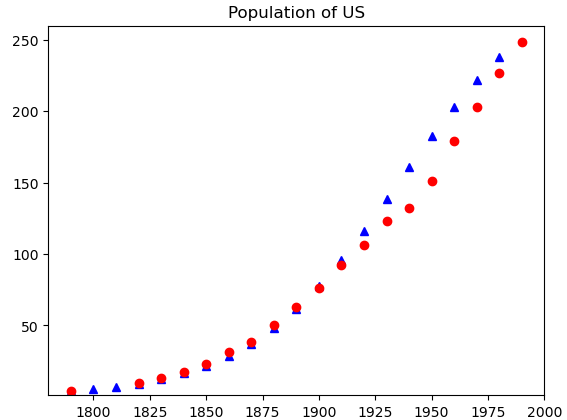

## Q.3 (*) Cohort Model
Consider the human population divided into three age groups $0-14$, $15-39$ and $\geq 40$
with population size $P_{i}$ , $i=1,2,3$ and yearly birth rates of 0, 0.06
and 0 and death rates of 0.005, 0.01 and 0.015, respectively.

## TASKS
(a). Show that ${\bf P}(t+1)={\bf AP}(t)$ where 
$${\bf P}=
\begin{bmatrix}
P_{1} \\ 
P_{2} \\ 
P_{3}%
\end{bmatrix} ,\quad {\bf A}=
\begin{bmatrix}
0.\,92867 & 0.06 & 0 \\ 
0.06\,63 & 0.\,9504 & 0 \\ 
0 & 0.0\,396 & 0.985%
\end{bmatrix}.$$

(b). Find the largest eigenvalue of ${\bf A}$ and describe the long-term
behaviour of this system. Compare a plot of the exact solution for 500 years versus the solution we get by just keeping the largest eigenvalue/eigenvector as in class notes. Set initial $P_{1}=P_{2}=P_{3}=100$ for this comparision. (This last part is the hardest question, and relies on you understanding the class notes; leave until last if you like)

(c). Consider the growth of the population with the following initial
populations. How long does it take for the total population to double in
each case?

$\quad$ (i)  $P_{1}=200$, $P_{2}=P_{3}=400$.
    
$\quad$   (ii) $P_{1}=400$, $P_{2}=P_{3}=300$.
    
$\quad$   (iii) $P_{1}=200$, $P_{2}=500$ and $P_{3}=300$.

Explain what you see.

In [22]:
b=[0, 0.06 ,0]
d=[0.005, 0.01, 0.015]

In [23]:
A=np.mat([[ #fill this in yourself
]])
# recall Python indexing begins at 0

In [24]:
print(A)

[[0.92866667 0.06       0.        ]
 [0.06633333 0.9504     0.        ]
 [0.         0.0396     0.985     ]]


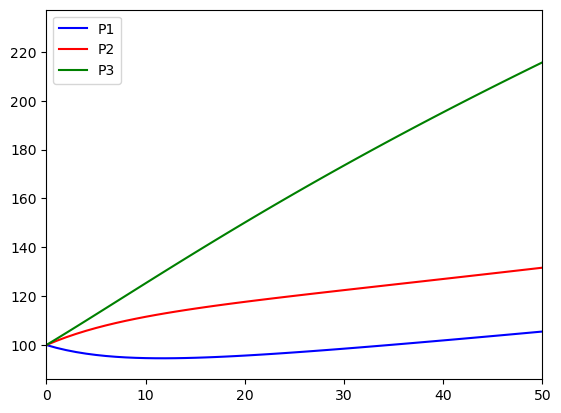

In [36]:
nit=500 # nit is no of time steps

#initialise list to zero

P1=[0]*(nit+1)
P2=[0]*(nit+1)
P3=[0]*(nit+1)

#Given initial population

P1[0],P2[0],P3[0]=100,100,100

# compute P1,P2,P3 
for n in range(1,nit+1):
    P1[n],P2[n],P3[n]=#figure this out

# plotting can use code like this

# t=np.arange(0,nit+1,1) #  time steps
# plt.figure()
# P1plot,=plt.plot(t,P1,'b-')
# P2plot,=plt.plot(t,P2,'r-')
# P3plot,=plt.plot(t,P3,'g-')
# plt.legend((P1plot,P2plot,P3plot),('P1','P2','P3'))
# Pmax=max(max(P1),max(P2),max(P3))
# Pmin=min(min(P1),min(P1),min(P1))
# plt.axis([0,nit,Pmin/1.1,Pmax*1.1])
# plt.show()

The plot should end up looking something like this

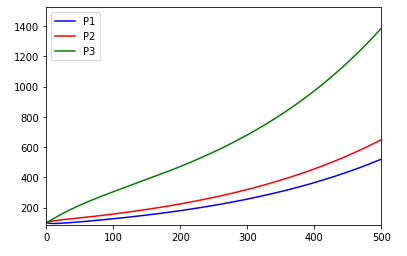

## Q.4 (*) Chaotic Models 
Consider the Ricker model of Salmon population size as follows 

$$
P_{n+1}=re^{-\frac{P_{n}}{K}}P_{n} 
$$

where $r$ is the rate and $K$ is another parameter. 

## TASKS

For simplicity choose $K=500$ and consider the behaviour of this system for

(a). $r<1$, with initial population of $1000$.

(b). $1<r<e^{2}$, for initial population 100, 500 and 1000.

(c). $r>e^{2}$, for initial population 100, 500 and 1000.

Explain what you see.

In [ ]:
nit=100 # nit is no of time steps
t=np.arange(0,nit+1,1) #  time steps



# initial values
P_0=1000. # initial population takes different values
K=500. # K=threshold stays the same
r=8 #this is case (c)


P=[0]*(nit+1) # list for P initialized with nit zeros
P[0]=P_0 # given initial population
for n in range(1,nit+1):
    P[n]=r*P[n-1]*np.exp(-P[n-1]/K) 

# plotting 
plt.figure()
plt.plot(t,P,'b.')
Pmax=max(P)
Pmin=min(P)
plt.axis([0,nit+1,Pmin/1.1,Pmax*1.1])
plt.title('Salmon Population for P0 =' +str(P_0)+ ' and r = ' +str(r))
plt.show()

Should observe that population dies out for $r<1$. 

Explore the other values of $r$ where one can find convergence to non-zero population for $1<r<e^{2}$ and period doubling phenomena and chaos for $r>e^{2}$.

Useful fact about $e^2$ in Python:

In [ ]:
print(np.exp(1))
e2=np.exp(2)
print(e2)